In [1]:
import fa2

In [2]:
import scenvi

In [3]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # Change to -1 if you want to use CPU!

import warnings
warnings.filterwarnings('ignore')

In [4]:

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
import umap.umap_ as umap
from fa2 import ForceAtlas2

In [5]:
def flatten(arr):
    return(np.reshape(arr, [arr.shape[0], -1]))

def force_directed_layout(affinity_matrix, cell_names=None, verbose=True, iterations=500, device='cpu'):
    """" Function to compute force directed layout from the affinity_matrix
    :param affinity_matrix: Sparse matrix representing affinities between cells
    :param cell_names: pandas Series object with cell names
    :param verbose: Verbosity for force directed layout computation
    :param iterations: Number of iterations used by ForceAtlas
    :return: Pandas data frame representing the force directed layout
    """

    init_coords = np.random.random((affinity_matrix.shape[0], 2))

    if device == 'cpu':
        forceatlas2 = ForceAtlas2(
            # Behavior alternatives
            outboundAttractionDistribution=False,
            linLogMode=False,
            adjustSizes=False,
            edgeWeightInfluence=1.0,
            # Performance
            jitterTolerance=1.0,
            barnesHutOptimize=True,
            barnesHutTheta=1.2,
            multiThreaded=False,
            # Tuning
            scalingRatio=2.0,
            strongGravityMode=False,
            gravity=1.0,
            # Log
            verbose=verbose)

        positions = forceatlas2.forceatlas2(
            affinity_matrix, pos=init_coords, iterations=iterations)
        positions = np.array(positions)


    positions = pd.DataFrame(positions,
                             index=np.arange(affinity_matrix.shape[0]), columns=['x', 'y'])
    return positions

def run_diffusion_maps(data_df, n_components=10, knn=30, alpha=0):
    """Run Diffusion maps using the adaptive anisotropic kernel
    :param data_df: PCA projections of the data or adjacency matrix
    :param n_components: Number of diffusion components
    :param knn: Number of nearest neighbors for graph construction
    :param alpha: Normalization parameter for the diffusion operator
    :return: Diffusion components, corresponding eigen values and the diffusion operator
    """

    # Determine the kernel
    N = data_df.shape[0]

    if(type(data_df).__module__ == np.__name__):
        data_df = pd.DataFrame(data_df)

    if not scipy.sparse.issparse(data_df):
        print("Determing nearest neighbor graph...")
        temp = sc.AnnData(data_df.values)
        sc.pp.neighbors(temp, n_pcs=0, n_neighbors=knn)
        kNN = temp.obsp['distances']

        # Adaptive k
        adaptive_k = int(np.floor(knn / 3))
        adaptive_std = np.zeros(N)

        for i in np.arange(len(adaptive_std)):
            adaptive_std[i] = np.sort(kNN.data[kNN.indptr[i] : kNN.indptr[i + 1]])[
                adaptive_k - 1
            ]

        # Kernel
        x, y, dists = scipy.sparse.find(kNN)

        # X, y specific stds
        dists = dists / adaptive_std[x]
        W = scipy.sparse.csr_matrix((np.exp(-dists), (x, y)), shape=[N, N])

        # Diffusion components
        kernel = W + W.T
    else:
        kernel = data_df

    # Markov
    D = np.ravel(kernel.sum(axis=1))

    if alpha > 0:
        # L_alpha
        D[D != 0] = D[D != 0] ** (-alpha)
        mat = scipy.sparse.csr_matrix((D, (range(N), range(N))), shape=[N, N])
        kernel = mat.dot(kernel).dot(mat)
        D = np.ravel(kernel.sum(axis=1))

    D[D != 0] = 1 / D[D != 0]
    T = scipy.sparse.csr_matrix((D, (range(N), range(N))), shape=[N, N]).dot(kernel)
    # Eigen value dcomposition
    D, V = scipy.sparse.linalg.eigs(T, n_components, tol=1e-4, maxiter=1000)
    D = np.real(D)
    V = np.real(V)
    inds = np.argsort(D)[::-1]
    D = D[inds]
    V = V[:, inds]

    # Normalize
    for i in range(V.shape[1]):
        V[:, i] = V[:, i] / np.linalg.norm(V[:, i])

    # Create are results dictionary
    res = {"T": T, "EigenVectors": V, "EigenValues": D}
    res["EigenVectors"] = pd.DataFrame(res["EigenVectors"])
    if not scipy.sparse.issparse(data_df):
        res["EigenVectors"].index = data_df.index
    res["EigenValues"] = pd.Series(res["EigenValues"])
    res["kernel"] = kernel

    return res


def FDL(data, k = 30):


    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=int(k), metric='euclidean',
                               n_jobs=5).fit(data)
    kNN = nbrs.kneighbors_graph(data, mode='distance')
    # Adaptive k

    adaptive_k = int(np.floor(k / 3))
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=int(adaptive_k),
                           metric='euclidean', n_jobs=5).fit(data)
    adaptive_std = nbrs.kneighbors_graph(data, mode='distance').max(axis=1)
    adaptive_std = np.ravel(adaptive_std.todense())
    # Kernel
    x, y, dists = scipy.sparse.find(kNN)
    # X, y specific stds
    dists = dists / adaptive_std[x]
    N = data.shape[0]
    W = scipy.sparse.csr_matrix((np.exp(-dists), (x, y)), shape=[N, N])
    # Diffusion components
    kernel = W + W.T
    layout = force_directed_layout(kernel)
    return(layout)

In [6]:
sc_data = sc.read_h5ad('/Users/anushka/Undergraduate-Project/MERFISH_Data/sc_data_1.h5ad')

In [7]:
sc_data

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg'
    layers: 'log'

In [8]:
st_data= sc.read_h5ad('/Users/anushka/Undergraduate-Project/MERFISH_Data/st_data_processed.h5ad')

In [9]:
st_data

AnnData object with n_obs × n_vars = 223626 × 254
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label', 'Layer_Depth', 'Depth', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'n_iso', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

In [10]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

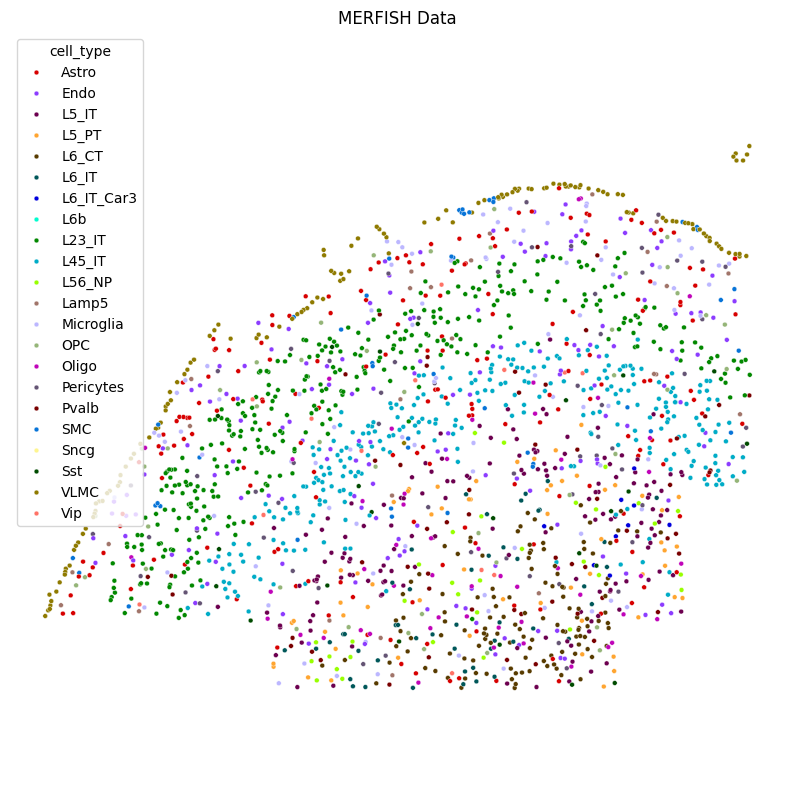

In [11]:
plt.figure(figsize=(10,10))

sns.scatterplot(x = st_data.obsm['spatial'][st_data.obs['batch'] == 'mouse1_slice10'][:, 1],
                y = -st_data.obsm['spatial'][st_data.obs['batch'] == 'mouse1_slice10'][:, 0], legend = True,
                hue = st_data.obs['cell_type'][st_data.obs['batch'] == 'mouse1_slice10'],
                s = 12, palette = cell_type_palette)
plt.axis('equal')
plt.axis('off')
plt.title("MERFISH Data")
plt.show()

In [12]:
fit = umap.UMAP(
    n_neighbors = 100,
    min_dist = 0.8,
    n_components = 2,
)

sc_data.layers['log'] = np.log(sc_data.X + 1)
sc.pp.highly_variable_genes(sc_data, layer = 'log', n_top_genes = 2048)
sc_data.obsm['UMAP_exp'] = fit.fit_transform(np.log(sc_data[:, sc_data.var['highly_variable']].X + 1))

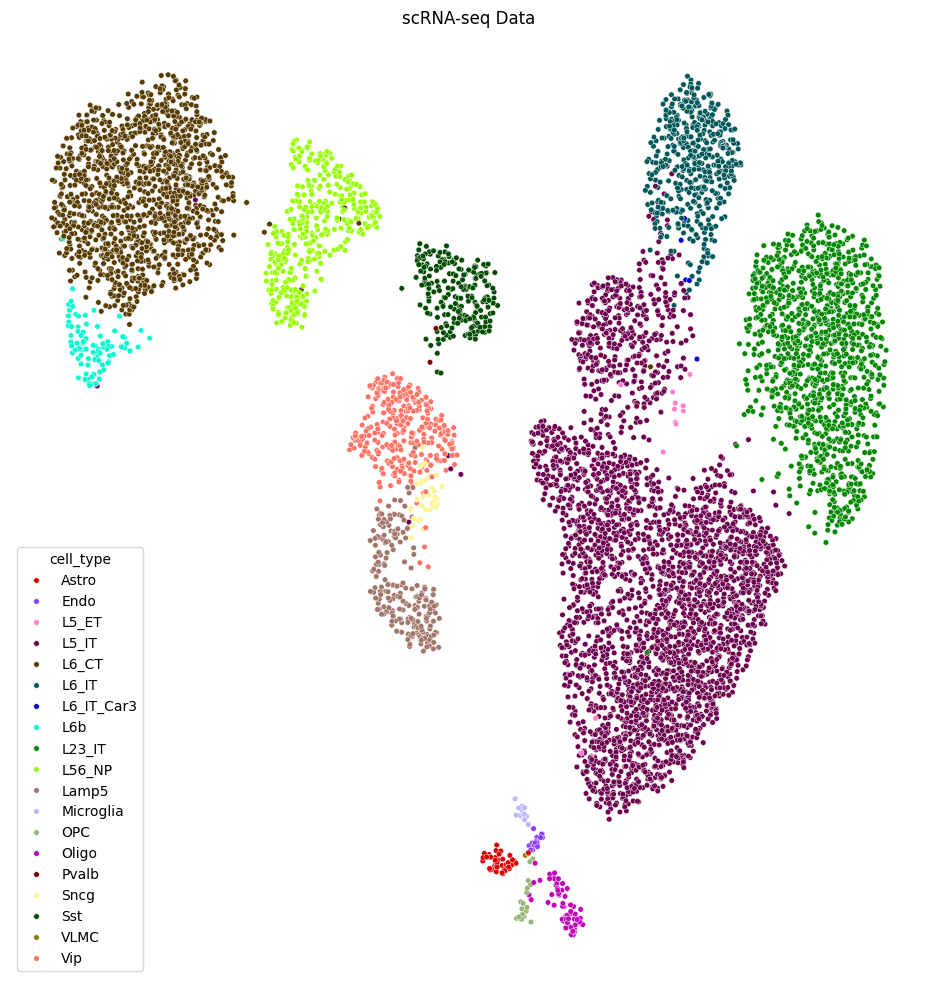

In [13]:
fig = plt.figure(figsize = (10,10))
sns.scatterplot(x = sc_data.obsm['UMAP_exp'][:, 0], y = sc_data.obsm['UMAP_exp'][:, 1],  hue = sc_data.obs['cell_type'], s = 16,
                palette = cell_type_palette, legend = True)
plt.tight_layout()
plt.axis('off')
plt.title('scRNA-seq Data')
plt.show()

In [14]:
import tensorflow as tf
import scenvi

In [15]:
envi_model = scenvi.ENVI(spatial_data = st_data, sc_data = sc_data)

DEBUG
Computing Niche Covariance Matrices
Initializing CVAE
Finished Initializing ENVI


In [20]:
envi_model.train(training_steps=5000)


 spatial: -6.502e-01 sc: -1.145e+00 cov: -6.548e-03 kl: 7.978e-01: 100%|██████████| 5000/5000 [18:32<00:00,  4.49it/s]


In [21]:
envi_model.impute_genes()


Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENVI.spatial_data


In [22]:
envi_model.infer_niche_covet()


In [23]:
envi_model.infer_niche_celltype()

In [24]:
st_data.obsm['envi_latent'] = envi_model.spatial_data.obsm['envi_latent']
st_data.obsm['COVET'] = envi_model.spatial_data.obsm['COVET']
st_data.obsm['COVET_SQRT'] = envi_model.spatial_data.obsm['COVET_SQRT']
st_data.uns['COVET_genes'] =  envi_model.CovGenes
st_data.obsm['imputation'] = envi_model.spatial_data.obsm['imputation']
st_data.obsm['cell_type_niche'] = envi_model.spatial_data.obsm['cell_type_niche']

sc_data.obsm['envi_latent'] = envi_model.sc_data.obsm['envi_latent']
sc_data.obsm['COVET'] = envi_model.sc_data.obsm['COVET']
sc_data.obsm['COVET_SQRT'] = envi_model.sc_data.obsm['COVET_SQRT']
sc_data.obsm['cell_type_niche'] = envi_model.sc_data.obsm['cell_type_niche']
sc_data.uns['COVET_genes'] =  envi_model.CovGenes

# UMAP FOR ENVI LATENT


In [25]:
fit = umap.UMAP(
    n_neighbors = 100,
    min_dist = 0.3,
    n_components = 2,
)

latent_umap = fit.fit_transform(np.concatenate([st_data.obsm['envi_latent'], sc_data.obsm['envi_latent']], axis = 0))

st_data.obsm['latent_umap'] = latent_umap[:st_data.shape[0]]
sc_data.obsm['latent_umap'] = latent_umap[st_data.shape[0]:]

In [26]:
lim_arr = np.concatenate([st_data.obsm['latent_umap'], sc_data.obsm['latent_umap']], axis = 0)


delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta


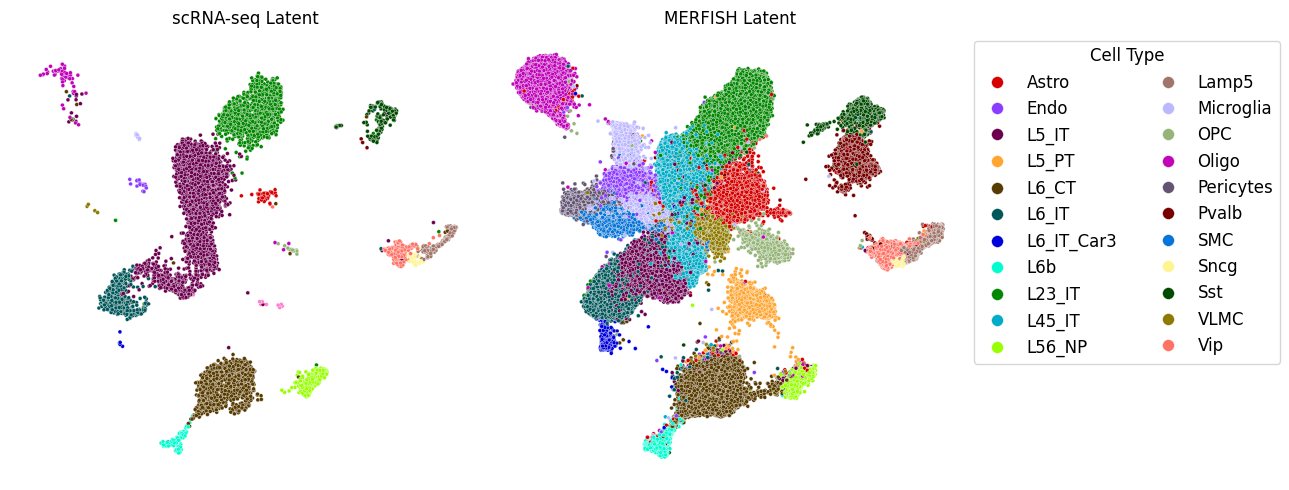

In [27]:
fig = plt.figure(figsize = (13,5))
plt.subplot(121)
sns.scatterplot(x = sc_data.obsm['latent_umap'][:, 0],
                y = sc_data.obsm['latent_umap'][:, 1], hue = sc_data.obs['cell_type'], s = 8, palette = cell_type_palette,
                legend = False)
plt.title("scRNA-seq Latent")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')

plt.subplot(122)
sns.scatterplot(x = st_data.obsm['latent_umap'][:, 0],
                y = st_data.obsm['latent_umap'][:, 1],  hue = st_data.obs['cell_type'], s = 8, palette = cell_type_palette, legend = True)


legend = plt.legend(title = 'Cell Type', prop={'size': 12}, fontsize = '12',  markerscale = 3, ncol = 2, bbox_to_anchor = (1, 1))#, loc = 'lower left')
plt.setp(legend.get_title(),fontsize='12')
plt.title("MERFISH Latent")
plt.axis('off')
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.show()

In [41]:
print("Shape of st_data.obsm['COVET_SQRT']:", st_data.obsm['COVET_SQRT'].shape)
print("Shape of sc_data.obsm['COVET_SQRT']:", sc_data.obsm['COVET_SQRT'].shape)

Shape of st_data.obsm['COVET_SQRT']: (223626, 62, 62)
Shape of sc_data.obsm['COVET_SQRT']: (7416, 62, 62)


In [43]:
st_data.obsm['COVET_SQRT'] = np.mean(st_data.obsm['COVET_SQRT'], axis=2)  # Assuming the extra dimension is the 3rd dimension (axis=2)
sc_data.obsm['COVET_SQRT'] = np.mean(sc_data.obsm['COVET_SQRT'], axis=2)

# UMAP FOR COVET SQRT

In [44]:
fit = umap.UMAP(
    n_neighbors = 100,
    min_dist = 0.3,
    n_components = 2,
)

covet_sqrt_umap = fit.fit_transform(np.concatenate([st_data.obsm['COVET_SQRT'], sc_data.obsm['COVET_SQRT']], axis = 0))

st_data.obsm['COVET_SQRT'] = covet_sqrt_umap[:st_data.shape[0]]
sc_data.obsm['COVET_SQRT'] = covet_sqrt_umap[st_data.shape[0]:]

In [46]:
lim_arr = np.concatenate([st_data.obsm['COVET_SQRT'], sc_data.obsm['COVET_SQRT']], axis = 0)


delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta


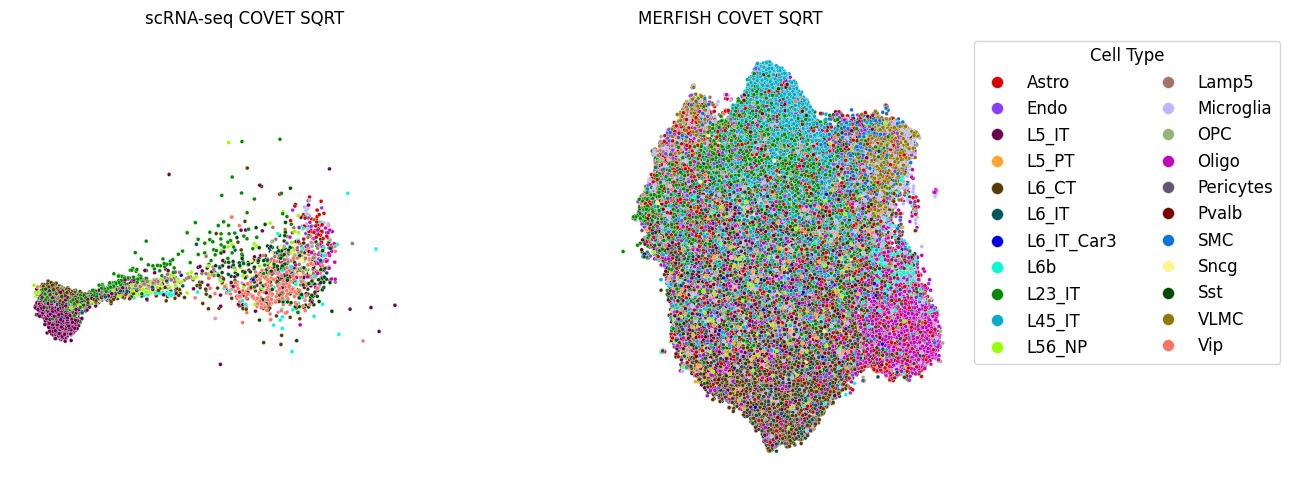

In [48]:
fig = plt.figure(figsize = (13,5))
plt.subplot(121)
sns.scatterplot(x = sc_data.obsm['COVET_SQRT'][:, 0],
                y = sc_data.obsm['COVET_SQRT'][:, 1], hue = sc_data.obs['cell_type'], s = 8, palette = cell_type_palette,
                legend = False)
plt.title("scRNA-seq COVET SQRT")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')

plt.subplot(122)
sns.scatterplot(x = st_data.obsm['COVET_SQRT'][:, 0],
                y = st_data.obsm['COVET_SQRT'][:, 1],  hue = st_data.obs['cell_type'], s = 8, palette = cell_type_palette, legend = True)


legend = plt.legend(title = 'Cell Type', prop={'size': 12}, fontsize = '12',  markerscale = 3, ncol = 2, bbox_to_anchor = (1, 1))#, loc = 'lower left')
plt.setp(legend.get_title(),fontsize='12')
plt.title("MERFISH COVET SQRT")
plt.axis('off')
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.show()

In [28]:
st_data_sst = st_data[st_data.obs['cell_type'] == 'Sst']
sc_data_sst = sc_data[sc_data.obs['cell_type'] == 'Sst']

In [29]:
gran_sst_palette = {'Th': (0.0, 0.294118, 0.0, 1.0),
                    'Calb2': (0.560784, 0.478431, 0.0, 1.0),
                    'Chodl': (1.0, 0.447059, 0.4, 1.0),
                    'Myh8': (0.933333, 0.72549, 0.72549, 1.0),
                    'Crhr2': (0.368627, 0.494118, 0.4, 1.0),
                    'Hpse': (0.65098, 0.482353, 0.72549, 1.0),
                    'Hspe': (0.352941, 0.0, 0.643137, 1.0),
                    'Crh': (0.607843, 0.894118, 1.0, 1.0),
                    'Pvalb Etv1': (0.92549, 0.0, 0.466667, 1.0)}

In [30]:


FDL_COVET = np.asarray(FDL(np.concatenate([flatten(st_data_sst.obsm['COVET_SQRT']),
                                           flatten(sc_data_sst.obsm['COVET_SQRT'])], axis = 0), k = 30))

st_data_sst.obsm['FDL_COVET'] = FDL_COVET[:st_data_sst.shape[0]]
sc_data_sst.obsm['FDL_COVET'] = FDL_COVET[st_data_sst.shape[0]:]

100%|██████████| 500/500 [00:11<00:00, 43.66it/s]


BarnesHut Approximation  took  5.27  seconds
Repulsion forces  took  5.47  seconds
Gravitational forces  took  0.04  seconds
Attraction forces  took  0.23  seconds
AdjustSpeedAndApplyForces step  took  0.23  seconds


In [31]:
DC_COVET = np.asarray(run_diffusion_maps(np.concatenate([flatten(st_data_sst.obsm['COVET_SQRT']),
                                                         flatten(sc_data_sst.obsm['COVET_SQRT'])], axis = 0), knn = 30)['EigenVectors'])[:, 1:]
st_data_sst.obsm['DC_COVET'] = -DC_COVET[:st_data_sst.shape[0]]
sc_data_sst.obsm['DC_COVET'] = -DC_COVET[st_data_sst.shape[0]:]

Determing nearest neighbor graph...


In [32]:
st_data_sst.obsm['DC_COVET'] = -DC_COVET[:st_data_sst.shape[0]]
sc_data_sst.obsm['DC_COVET'] = -DC_COVET[st_data_sst.shape[0]:]

In [36]:
lim_arr = np.concatenate([st_data_sst.obsm['FDL_COVET'], sc_data_sst.obsm['FDL_COVET']], axis = 0)


delta = 1000
pre = 0.01
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta

KeyError: 'cluster_label'

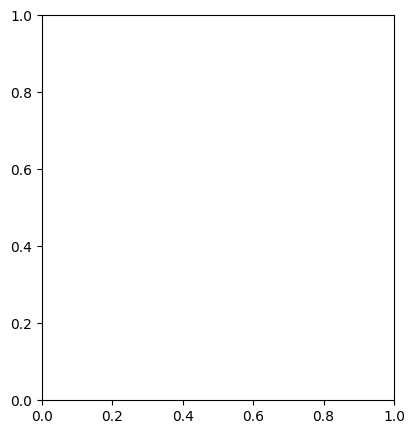

In [37]:
plt.figure(figsize=(10,5))

plt.subplot(121)
sns.scatterplot(x = sc_data_sst.obsm['FDL_COVET'][:, 0],
                y = sc_data_sst.obsm['FDL_COVET'][:, 1],
                hue = sc_data_sst.obs['cluster_label'], s = 16,  palette= gran_sst_palette, legend = True)
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.title('scRNA-seq Sst, COVET FDL')
legend = plt.legend(title = 'Sst subtype', prop={'size': 8}, fontsize = '8',  markerscale = 1, ncol = 2)
plt.axis('off')

plt.subplot(122)
ax = sns.scatterplot(x = st_data_sst.obsm['FDL_COVET'][:, 0],
                y = st_data_sst.obsm['FDL_COVET'][:, 1],
                c = st_data_sst.obsm['DC_COVET'][:,0], s = 16,  cmap= 'cet_CET_D13', legend = False)
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')
plt.title('MERFISH Sst, COVET FDL')
plt.show()

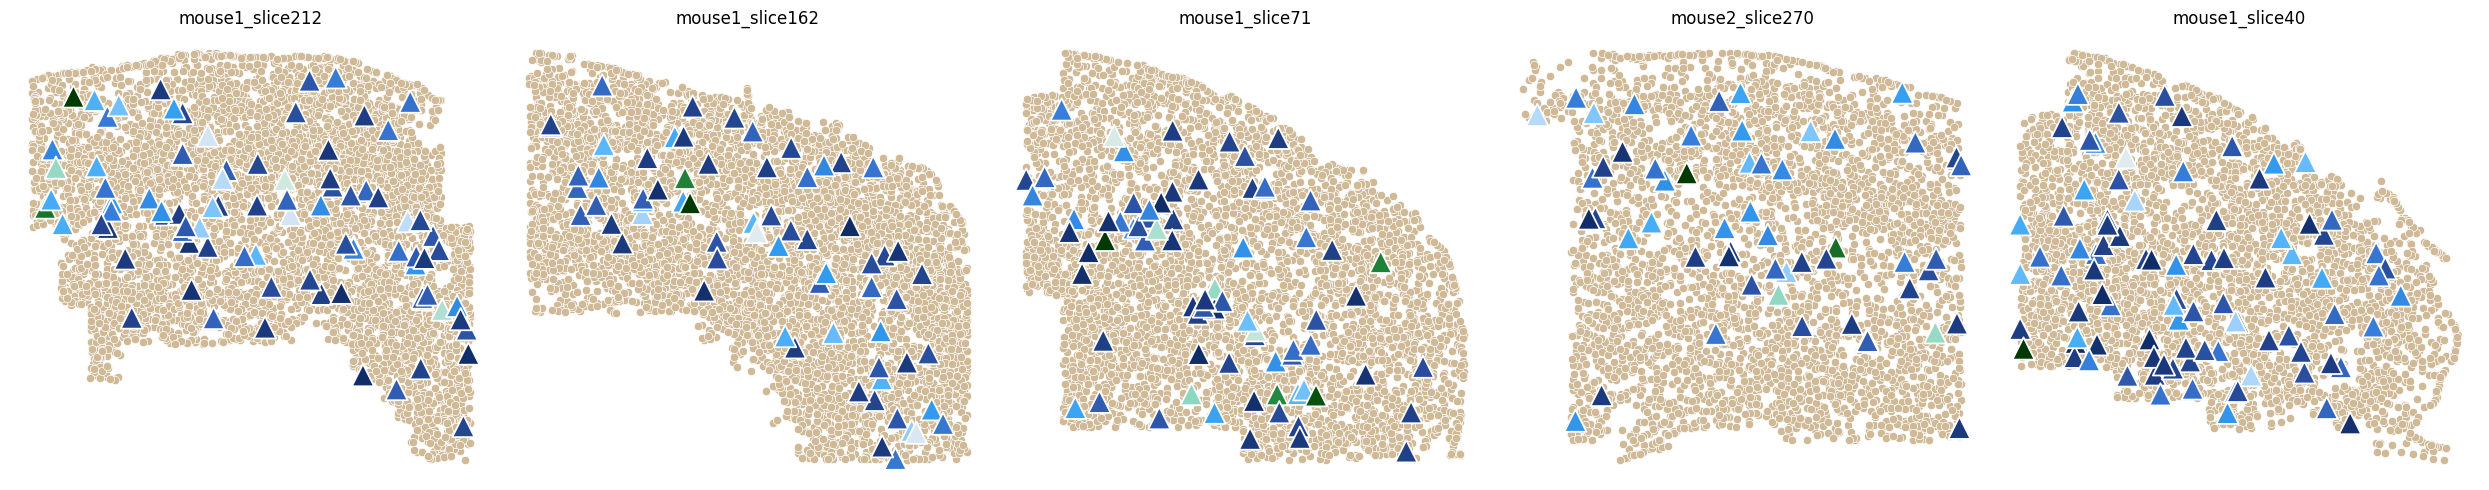

In [38]:
fig = plt.figure(figsize=(25,5))

for ind, batch in enumerate(['mouse1_slice212', 'mouse1_slice162', 'mouse1_slice71', 'mouse2_slice270', 'mouse1_slice40']):
    st_dataBatch = st_data[st_data.obs['batch'] == batch]
    st_dataPlotBatch = st_data_sst[st_data_sst.obs['batch'] == batch]

    plt.subplot(1,5, 1+ ind)
    sns.scatterplot(x = st_dataBatch.obsm['spatial'][:, 0], y = st_dataBatch.obsm['spatial'][:, 1],  color = (207/255,185/255,151/255, 1))
    sns.scatterplot(x = st_dataPlotBatch.obsm['spatial'][:, 0], y = st_dataPlotBatch.obsm['spatial'][:, 1], marker = '^',
                        c = st_dataPlotBatch.obsm['DC_COVET'][:, 0], s = 256,  cmap= 'cet_CET_D13', legend = False)
    plt.title(batch)
    plt.axis('off')
    plt.tight_layout()

plt.show()

In [ ]:
depth_df = pd.DataFrame()
depth_df['Subtype'] = sc_data_sst.obs['cluster_label']
depth_df['Depth'] = -sc_data_sst.obsm['DC_COVET'][:,0]

In [ ]:
subtype_depth_order = depth_df.groupby(['Subtype']).mean().sort_values(by = 'Depth', ascending=False).index


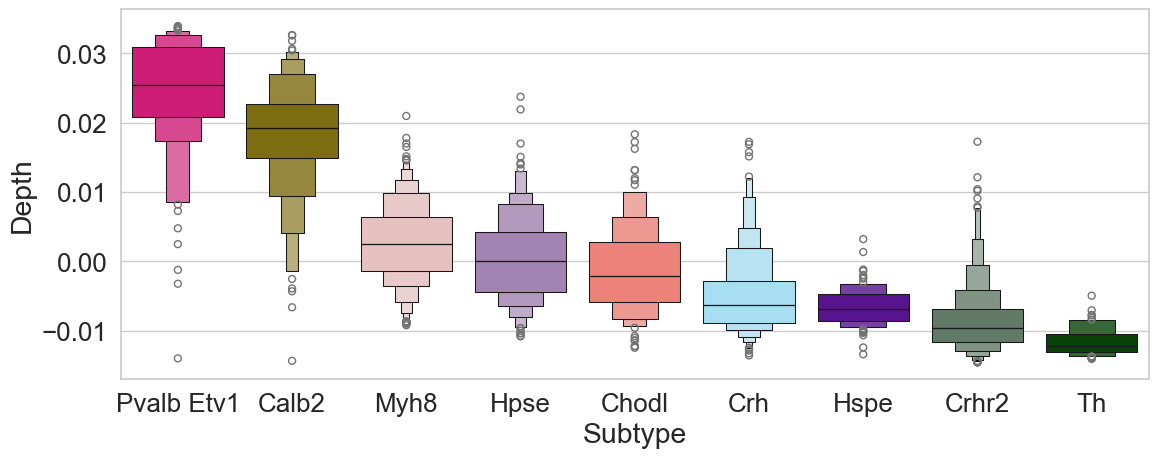

In [ ]:
plt.figure(figsize=(12,5))
sns.set(font_scale=1.7)
sns.set_style("whitegrid")
sns.boxenplot(depth_df, x = 'Subtype', y = 'Depth',# bw = 1, width = 0.9,
          order = subtype_depth_order,
          palette = gran_sst_palette)
plt.tight_layout()
plt.show()

In [ ]:
subtype_canonical = pd.DataFrame([sc_data_sst[sc_data_sst.obs['cluster_label']==subtype].obsm['cell_type_niche'].mean(axis = 0) for subtype in subtype_depth_order],
                                     index = subtype_depth_order, columns = sc_data.obsm['cell_type_niche'].columns)

In [ ]:
subtype_canonical[subtype_canonical<0.2] = 0
subtype_canonical.drop(labels=subtype_canonical.columns[(subtype_canonical == 0).all()], axis=1, inplace=True)
subtype_canonical = subtype_canonical.div(subtype_canonical.sum(axis=1), axis=0)


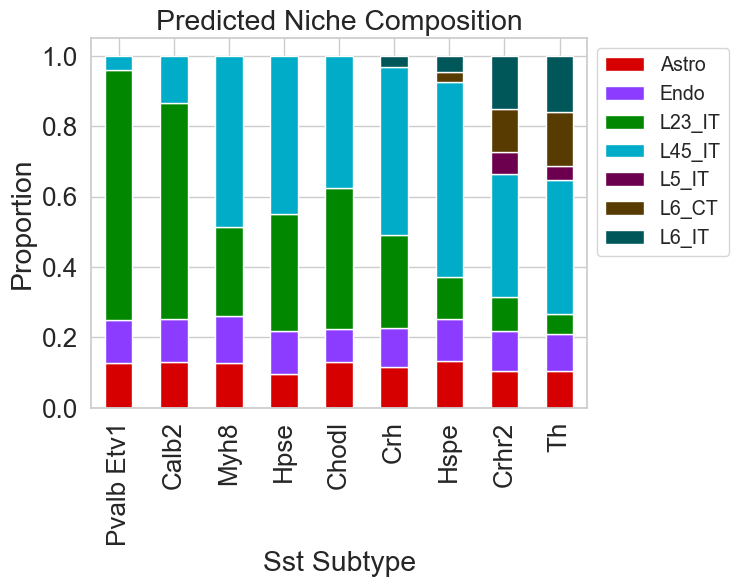

In [ ]:
subtype_canonical.plot(kind = 'bar', stacked = 'True',
                       color = {col:cell_type_palette[col] for col in subtype_canonical.columns})
plt.legend(bbox_to_anchor = (1,1), ncols = 1, fontsize = 'x-small')
plt.title("Predicted Niche Composition")
plt.ylabel("Proportion")
plt.xlabel("Sst Subtype")
plt.show()

In [ ]:
tick_genes = np.asarray(['Adamts18','Pamr1', 'Dkkl1', 'Hs6st2', 'Slit1', 'Ighm'])


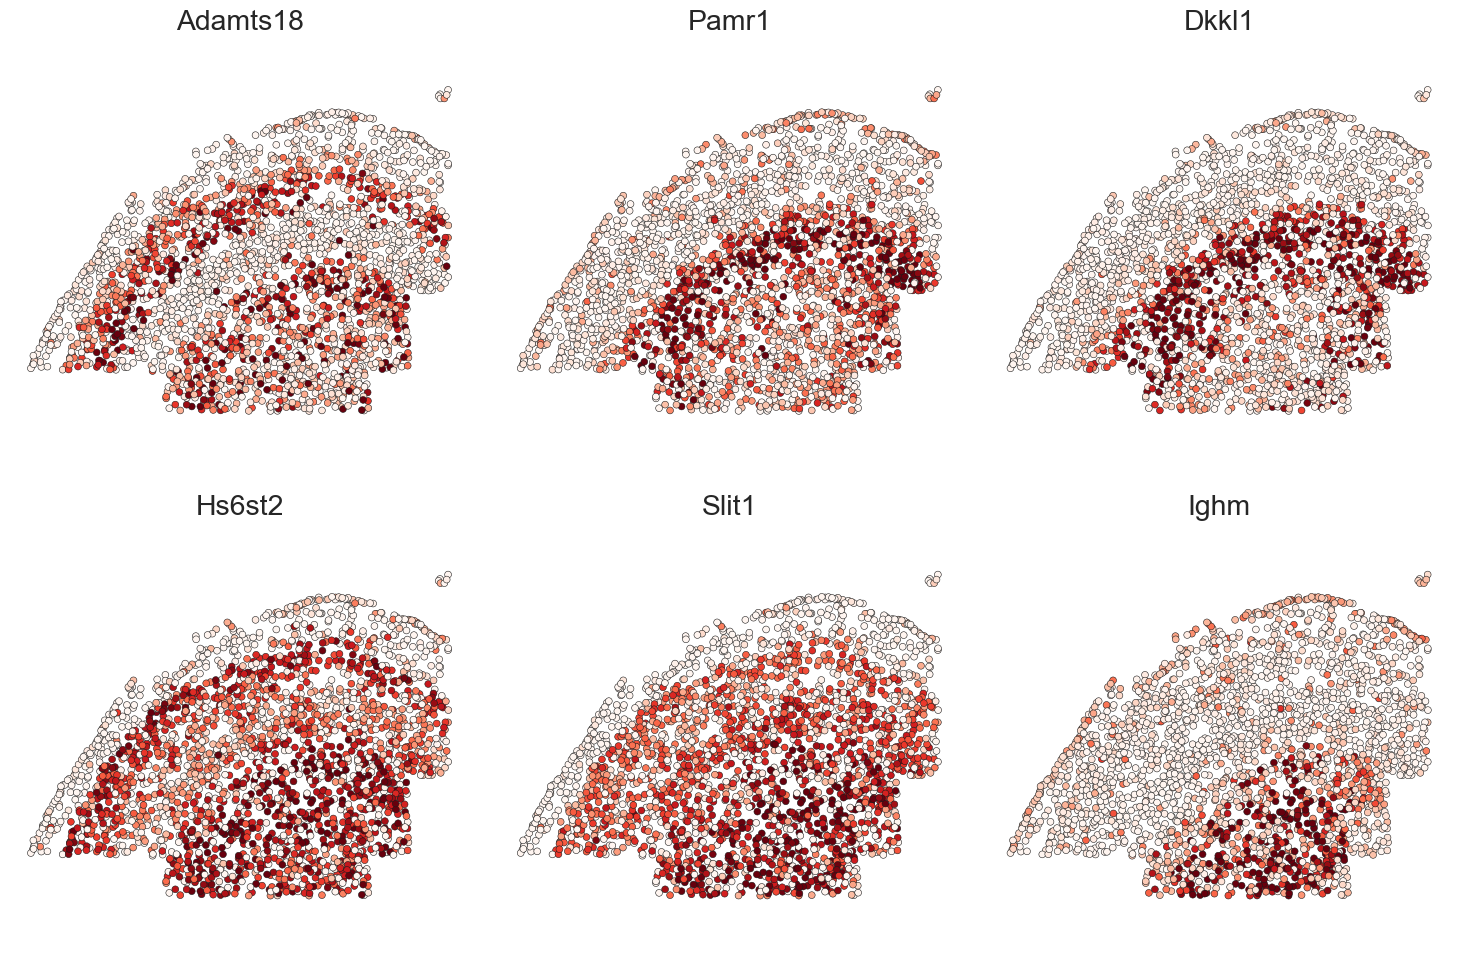

In [ ]:

plt.figure(figsize=(15,10))

for ind, gene in enumerate(tick_genes):
    plt.subplot(2,3,1+ind)

    cvec = np.log(st_data[st_data.obs['batch'] == 'mouse1_slice10'].obsm['imputation'][gene] + 0.1)
    sns.scatterplot(x = st_data.obsm['spatial'][st_data.obs['batch'] == 'mouse1_slice10'][:, 1],
                    y = -st_data.obsm['spatial'][st_data.obs['batch'] == 'mouse1_slice10'][:, 0], legend = False,
                    c = cvec, cmap = 'Reds',
                    vmax = np.percentile(cvec, 95), vmin = np.percentile(cvec, 30),
                    s = 24, edgecolor = 'k')#, palette = cell_type_palette)
    plt.title(gene)
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
plt.show()